# Info 2950 Final Project Phase 2

## Research Questions

Question: Can we accurately predict the daily bike rental sharing count based on the environmental conditions (weather, temp, hum, windspeed) and the timing (workdays vs. weekends, time of day)?

In this analysis, we aim to explore correlations between daily bike rental counts and various factors. Specifically, we will investigate the relationships between temperature, humidity, wind speed, weather conditions and workdays vs. weekend. We will train a multivariable regression model to see if we can reliably predict the number of daily bike rentals based on these environmental and holiday conditions.

## Data Cleaning

We first imported packages we thought would be important to data cleaning. These are the packages we normally use in our homeworks.

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import datetime

We downloaded the data from UC Irvine Machine Learning Repository in the form of a .csv file. To perform data cleaning, we placed the .csv file in the same folder as our Phase 2 .ipynb file. We loaded the dataset with pd.read_csv to variable named `data`.

In [2]:
# load data
data = pd.read_csv("hour.csv")
print(data.head())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  


We checked for the amount of null values and found none.

In [3]:
print(data.isnull().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


The `causal` and `registered` columns represent the number of bike renters who did not register their information with Capital Bike Sharing (CBS) and those who did, respectively. They add up to be the `cnt` (count) column of our dataframe. 

Our group is not interested in differentiating between the users of rental bikes, but instead we want to focus on the total count. This, our group chose to delete the `causal` and `registered` columns to make the dataframe cleaner. 


In [4]:
# remove "casual", "registered" column from the data
data = data.drop(data.columns[[-3, -2]], axis=1)
print(data.head())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  cnt  
0           1  0.24  0.2879  0.81        0.0   16  
1           1  0.22  0.2727  0.80        0.0   40  
2           1  0.22  0.2727  0.80        0.0   32  
3           1  0.24  0.2879  0.75        0.0   13  
4           1  0.24  0.2879  0.75        0.0    1  


The description for the `workingday` column is “if the day is neither weekend nor holiday is 1, otherwise is 0.” Since the `workingday` column is basically the `holiday` column but with more information, we decided to delete the `holiday` column. 

In [5]:
# remove the holiday column
data = data.drop(['holiday'], axis=1)
print(data.head())

   instant      dteday  season  yr  mnth  hr  weekday  workingday  weathersit  \
0        1  2011-01-01       1   0     1   0        6           0           1   
1        2  2011-01-01       1   0     1   1        6           0           1   
2        3  2011-01-01       1   0     1   2        6           0           1   
3        4  2011-01-01       1   0     1   3        6           0           1   
4        5  2011-01-01       1   0     1   4        6           0           1   

   temp   atemp   hum  windspeed  cnt  
0  0.24  0.2879  0.81        0.0   16  
1  0.22  0.2727  0.80        0.0   40  
2  0.22  0.2727  0.80        0.0   32  
3  0.24  0.2879  0.75        0.0   13  
4  0.24  0.2879  0.75        0.0    1  


The `instant` column is an index column. This is likely due to the fact that this data was imported and exported multiple times, by the author and our group. We will remove this column because we have the index of each row already.

In [6]:
# drop the first column "instant"
data = data.drop(['instant'], axis=1)
print(data.head())

       dteday  season  yr  mnth  hr  weekday  workingday  weathersit  temp  \
0  2011-01-01       1   0     1   0        6           0           1  0.24   
1  2011-01-01       1   0     1   1        6           0           1  0.22   
2  2011-01-01       1   0     1   2        6           0           1  0.22   
3  2011-01-01       1   0     1   3        6           0           1  0.24   
4  2011-01-01       1   0     1   4        6           0           1  0.24   

    atemp   hum  windspeed  cnt  
0  0.2879  0.81        0.0   16  
1  0.2727  0.80        0.0   40  
2  0.2727  0.80        0.0   32  
3  0.2879  0.75        0.0   13  
4  0.2879  0.75        0.0    1  


We convert the `dteday` (date of day) column to become a datetime variable column, so it will be easier to work with. `dtype('<M8[ns]')` represents datetime data.

In [7]:
data['dteday'] = pd.to_datetime(data['dteday'])
print(data['dteday'].dtype)

datetime64[ns]


Our group believes that it would be troublesome to interpret when our day is separated into 24 hours because there are 24 sections to look at! Thus, we decided to make the data more interpretable by only separating our day into four sections. 

To do this, we created the `time_period` column to include only four sections by grouping hours together:
- First section: hour 0-5 (dawn, 1)
- Second section: hour 6-11 (morning, 2)
- Third section: hour 12-17 (afternoon, 3)
- Fourth section: hour: 18-23 (night, 4)

In [8]:
# create a new column called "time_period" that assigns the hours into four groups: 1, 2, 3, 4
data = duckdb.sql("SELECT \
                      CASE \
                      WHEN hr BETWEEN 0 AND 5 THEN 1 \
                      WHEN hr BETWEEN 6 AND 11 THEN 2 \
                      WHEN hr BETWEEN 12 AND 17 THEN 3 \
                      WHEN hr BETWEEN 18 AND 23 THEN 4 \
                      END AS time_period, *\
                      FROM data").df()
data.head(10)

,time_period,dteday,season,yr,mnth,hr,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,2011-01-01,1,0,1,0,6,0,1,0.24,0.2879,0.81,0.0000,16
1,1,2011-01-01,1,0,1,1,6,0,1,0.22,0.2727,0.80,0.0000,40
2,1,2011-01-01,1,0,1,2,6,0,1,0.22,0.2727,0.80,0.0000,32
3,1,2011-01-01,1,0,1,3,6,0,1,0.24,0.2879,0.75,0.0000,13
4,1,2011-01-01,1,0,1,4,6,0,1,0.24,0.2879,0.75,0.0000,1
5,1,2011-01-01,1,0,1,5,6,0,2,0.24,0.2576,0.75,0.0896,1
6,2,2011-01-01,1,0,1,6,6,0,1,0.22,0.2727,0.80,0.0000,2
7,2,2011-01-01,1,0,1,7,6,0,1,0.20,0.2576,0.86,0.0000,3
8,2,2011-01-01,1,0,1,8,6,0,1,0.24,0.2879,0.75,0.0000,8
9,2,2011-01-01,1,0,1,9,6,0,1,0.32,0.3485,0.76,0.0000,14


After successfully creating the `time_period` column, our group deleted the `hour` column, as explained above.

In [9]:
# remove the hour column
data = data.drop(['hr'], axis=1)
print(data.head())

   time_period     dteday  season  yr  mnth  weekday  workingday  weathersit  \
0            1 2011-01-01       1   0     1        6           0           1   
1            1 2011-01-01       1   0     1        6           0           1   
2            1 2011-01-01       1   0     1        6           0           1   
3            1 2011-01-01       1   0     1        6           0           1   
4            1 2011-01-01       1   0     1        6           0           1   

   temp   atemp   hum  windspeed  cnt  
0  0.24  0.2879  0.81        0.0   16  
1  0.22  0.2727  0.80        0.0   40  
2  0.22  0.2727  0.80        0.0   32  
3  0.24  0.2879  0.75        0.0   13  
4  0.24  0.2879  0.75        0.0    1  


## Data Description

### What are the observations (rows) and the attributes (columns)?

The observations (rows) represent a particular time period each day from 2011 and 2012 in the Capital bikeshare system of bike-sharing data, where the weather, seasonal information, and the number of bike rentals is recorded.

The attributes (columns) includes:
- `time_period`: 
    - 1: Hour 0-5 (dawn)
    - 2: Hour 6-11 (morning)
    - 3: Hour 12-17 (afternoon)
    - 4: Hour: 18-23 (night)	
- `dteday`: date
- `season`: 
    - 1: Spring
    - 2: Summer
    - 3: Fall
    - 4: Winter
- `mnth`: month ( 1 to 12)
- `workingday`: if day is neither weekend nor holiday is 1, otherwise is 0.
- `weathersit_score`:
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- `temp`: Normalized temperature in Celsius. The values are divided to 41 (max)	
- `atemp`: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
- `hum`: Normalized humidity. The values are divided to 100 (max)	
- `windspeed`: Normalized wind speed. The values are divided to 67 (max)	
- `cnt`: count of total rental bikes including both casual and registered


### Why was this dataset created?

Hadi Fanaee-T and Joao Gama created this dataset to study how the number of bike rentals are influenced by various factors, including time and environmental conditions. It was used to develop models to predict the demand of bike-sharing, which is useful for planning and improving current bike-sharing systems.

### Who funded the creation of the dataset?

The creation of the bike-sharing dataset was funded by these sources:
1. European Regional Development Fund through the COMPETE Program.
2. Portuguese Funds through the Portuguese Foundation for Science and Technology (FCT) within the project FCOMP — 01-0124-FEDER-022701.
3. European Commission through the project MAESTRA (Grant Number ICT-2013-612944).


### What processes might have influenced what data was observed and recorded and what was not?


Since the data is related to a 2-year usage log of Capital Bike Sharing (CBS) at Washington, D.C., USA , the types of data observed and recorded are mostly for operational purposes. For example, the number of bikes rented per day was recorded for tracking and usage. CBS also needed to consider user privacy, so information such as user description and live bicycle location were not recorded.

### What preprocessing was done, and how did the data come to be in the form that you are using?


The authors normalized values for temperature, humidity, and wind speed to help the model reduce variance between different environmental variables. Additionally, my team and I deleted some attributes (columns) that we feel would be correlated with other attributes. We also transformed the observations (rows) from every hour to every time period (every six hours) because our results would be more interpretable to more readers. When transforming the hour data, we also transformed the weather data to be averaged out between the aggregated hours. 

### If people are involved, were they aware of the data collection and if so, what purpose did they expect the data to be used for?


The bikeshare users were probably not explicitly aware, but had a slight idea, that certain data from them was being collected. We believe these riders agreed to the general collection of data when using CBS by a terms and conditions agreement, which people usually skip through and agree. Generally, users would likely expect the data to be anonymized and used for operational improvements purposes. 


### Where can your raw source data be found, if applicable? Provide a link to the raw data (hosted on Github, in a Cornell Google Drive or Cornell Box)


Not applicable. We found our [dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) on UCI Machine Learning Repository. 


## Exploratory Data Analysis

We first look at the correlation and covariance between the `cnt` column, representing the total bike rent count, and all our variables (`time_period`, `dteday`, `season`, `weekday`, `workingday`, `temp`, `atemp`, `hum`, `windspeed`) in the cleaned dataset. 

The correlation and covariance can provide a rough estimate of the relationships between the weather related variables and the total bike rental count.

In [10]:
# corrleation between "cnt" and all variables in our dataset
print(f'Correlation: \n{data.corr()['cnt']}')
print('\n')
print(f'Covariance: \n{data.cov()['cnt']}')

Correlation: 
time_period    0.422126
dteday         0.277753
season         0.178056
yr             0.250495
mnth           0.120638
weekday        0.026900
workingday     0.030284
weathersit    -0.142426
temp           0.404772
atemp          0.400929
hum           -0.322911
windspeed      0.093234
cnt            1.000000
Name: cnt, dtype: float64


Covariance: 
time_period    8.542667e+01
dteday         9.144251e+17
season         3.575025e+01
yr             2.271869e+01
mnth           7.524796e+01
weekday        9.786763e+00
workingday     2.556708e+00
weathersit    -1.651736e+01
temp           1.413760e+01
atemp          1.249757e+01
hum           -1.130029e+01
windspeed      2.068951e+00
cnt            3.290146e+04
Name: cnt, dtype: float64


Observations:
1. Warmer temperatures (both temp and atemp) positively influence bike rentals, while higher humidity negatively influence bike rentals.
2. Windspeed seems to have little impact on bike rentals.

We want to explore the relationship between `weathersit` and `cnt`.
We would like to know if different weather situation are related to change in the total bike rental count. Below, we calculated the mean bike rental count for each weather situation and plot a boxplot. 

In [ ]:
# find the average of total bike rental count for each weather situation condition
weather_cnt_analyze = duckdb.sql("SELECT weathersit, AVG(cnt) AS cnt_avg\
                              FROM data \
                              GROUP BY weathersit \
                              ORDER BY weathersit").df()
print(weather_cnt_analyze)

,weathersit,cnt_avg
0,1,204.869272
1,2,175.165493
2,3,111.579281
3,4,74.333333


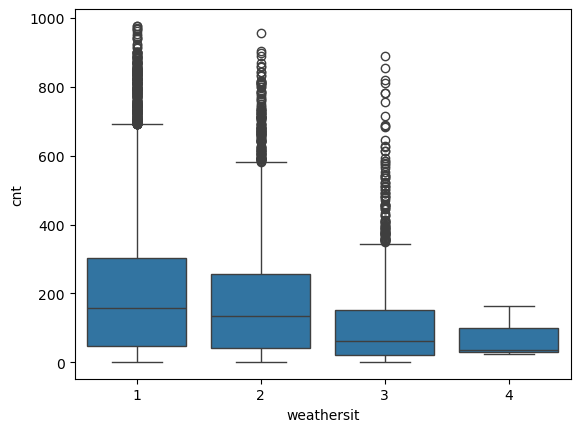

In [ ]:
# boxplot of weathersit_score and total rental count
sns.boxplot(data, x='weathersit', y='cnt');

Observations:
1. As the weather becomes worse (higher weathersit), bike rentals' average and median decrease, and there are fewer outliers.
2. Favorable weather conditions (lower weathersit) correspond with the highest number of bike rentals, with a wider range of values, suggesting that people are more likely to rent bikes on such days.

We also want to explore the total bike rental count change over time. Below is a line plot of total rental count based on the date.

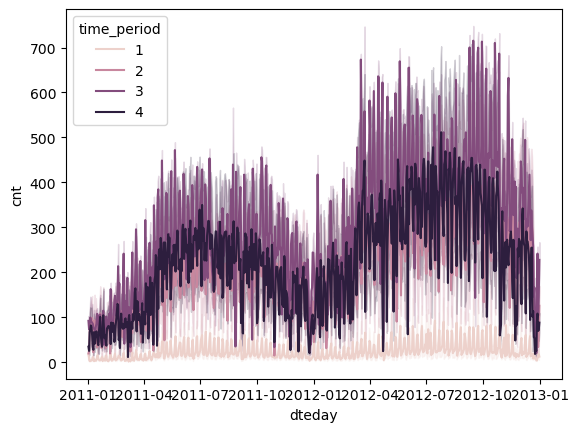

In [13]:
# plot the change of total rental count over time (day)
sns.lineplot(data, x='dteday', y='cnt', hue="time_period");

The graph above is too hard to read, but there is indeed some pattern occured over this time period. We decided to plot based on months.

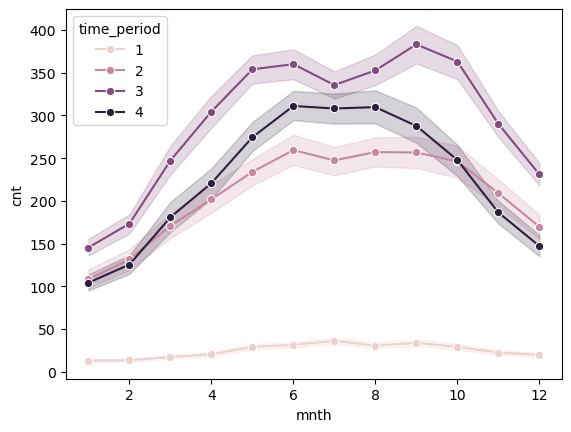

In [14]:
# plot the change of total rental count over time (months)
sns.lineplot(data, x='mnth', y='cnt', hue='time_period', marker='o');

Observations:
1. This graph shows the highest usage of bike rentals are during summer and the lowest during winter. 
2. Time period 3 (afternoon, hour 12-17) consistently sees the most rentals, while time period 1 (dawn, hour 0-5) has the least rentals. 

We want to explore how the change in time of the day can impact the total bike rental count. Below we calculated the average bike rental count for each time period of the day and produced a boxplot of total bike rental count based on time period.

   time_period     cnt_avg
0            1   24.908559
1            2  208.100688
2            3  295.483886
3            4  225.757555


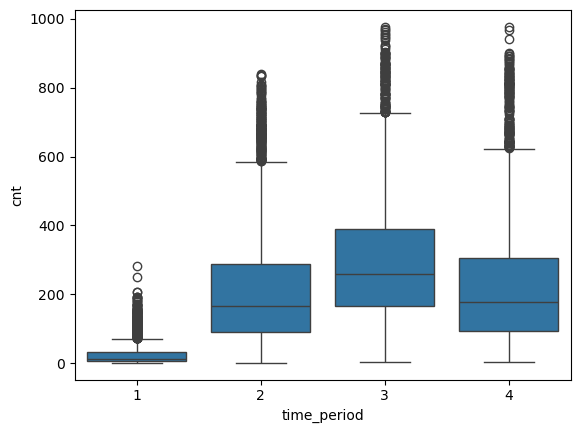

In [24]:
# find the mean of the total rental count for each time period
data_cnt_analyze = duckdb.sql("SELECT time_period, AVG(cnt) AS cnt_avg\
                              FROM data \
                              GROUP BY time_period \
                              ORDER BY time_period").df()
print(data_cnt_analyze)

# boxplot of time period and total rental count
sns.boxplot(data, x='time_period', y='cnt');

Observations:
1. Time period 3 (afternoon, hour 12-17) corresponds with the highest bike rental counts, while Time period 1 (dawn, hour 0-5) corresponds with the fewest.

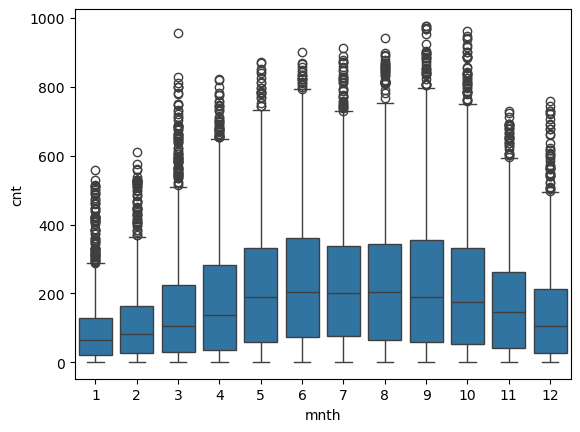

In [23]:
# boxplot of months and total rental count
sns.boxplot(data, x='mnth', y='cnt');

Observations:
1. Summer (June to August) corresponds with the most bike rentals, and winter (December and January) corresponds with the fewest.

## Data Limitations

1. Simplification of Environmental and Temporal Variables:  
The dataset applies normalized values for temperature, humidity, and wind speed to reduce variance in the model, but this may obscure the impact of extreme weather conditions on bike rentals. Additionally, aggregating hourly data into four time periods and selecting the primary weather condition within each period may overlook important short-term weather patterns that influence user behavior. This could affect the model's ability to capture fluctuations in bike demand under rapidly changing conditions.

2. Multicollinearity Among Independent Variables:  
There may be multicollinearity between variables such as working days, holidays, and weekdays due to their interdependence. This overlap increases the complexity of the model, making it more difficult to interpret the contribution of individual variables. Misinterpretation of the model could mislead decision-makers, resulting in inefficient resource allocation or policy decisions that fail to meet users' actual needs.

3. Limited Data Coverage:  
The dataset is limited to bike rental data from the Capital Bikeshare system in Washington, D.C., covering only the years 2011 to 2012. This temporal and geographical constraint may lead to data gaps, as the results might not generalize to other periods or locations with different usage patterns. Such limitations could affect the validity of predictions and insights, potentially leading to misinformed resource allocation or policy decisions if applied in contexts beyond the original dataset’s scope. 

Thoughtful consideration of these limitations ensures the responsible use of the findings and minimizes unintended impacts on stakeholders.

## Questions for Reviewers

- When dividing the time into four different groups, we add the corresponding “weathersit” values together then find the average for each group. This resulted in the absence of weather situation level 4 in the final dataframe. Is there a better way to find a common “weathersit” for each group?
- There may be multicollinearity between some variables in the dataframe. How might this impact our regression model and should we remove these variables?
- What are some aspects that we need to pay attention to when fitting a regression model in the future?